# Recommendation  functions

### Import the processed dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import ast





c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv("cleaned_sephora_dataset.csv", engine='python', encoding='utf-8')


## Recommend products by user features

The function filters products by comparing user attributes (skin_tone, skin_type, eye_color, hair_color) in a case-insensitive manner.



In [4]:
def recommend_products_by_user_features(skintone, skintype, eyecolor, haircolor, secondary_category="All", price_order=None, percentile=0.85):
    """
    Recommend top products for a user based on their features, selected product type,
    and optionally sort the recommendations by price.
    
    Parameters:
        skintone (str): The user's skin tone.
        skintype (str): The user's skin type.
        eyecolor (str): The user's eye color.
        haircolor (str): The user's hair color.
        secondary_category (str): The desired product type (e.g., 'moisturizers', 'cleansers').
                                  Use "All" to include all product types.
        price_order (str): If provided, must be either "asc" or "desc" to sort by price in ascending or descending order.
                           If None, sorting defaults to rating in descending order.
        percentile (float): (Optional) A percentile threshold (currently not used in the function).
        
    Returns:
        DataFrame: A DataFrame with the top 10 unique recommended products.
    """
    # Filter the DataFrame based on the user's features (case-insensitive)
    ddf = df[
        (df['skin_tone'].str.lower() == skintone.lower()) &
        (df['skin_type'].str.lower() == skintype.lower()) &
        (df['eye_color'].str.lower() == eyecolor.lower()) &
        (df['hair_color'].str.lower() == haircolor.lower())
    ]
    
    # Filter by secondary category if specified (exact match, then fallback to partial match)
    if secondary_category.lower() != "all":
        exact_match = ddf[ddf['secondary_category'].str.lower() == secondary_category.lower()]
        if not exact_match.empty:
            ddf = exact_match
        else:
            ddf = ddf[ddf['secondary_category'].str.contains(secondary_category.lower(), na=False)]
    
    # Ensure that the rating is not null and select key columns (including product_id)
    recommendations = ddf[ddf['rating'].notnull()][['product_id', 'rating', 'product_name', 'brand_name', 'price_usd', 'secondary_category']]
    
    # Sort by rating as default
    recommendations = recommendations.sort_values('rating', ascending=False)
    
    # Drop duplicate products based on product_id so each product appears only once
    recommendations = recommendations.drop_duplicates(subset=['product_id'])
    
    # If a price sorting order is specified, sort by price instead
    if price_order is not None:
        if price_order.lower() == "asc":
            recommendations = recommendations.sort_values('price_usd', ascending=True)
        elif price_order.lower() == "desc":
            recommendations = recommendations.sort_values('price_usd', ascending=False)
        else:
            print("Invalid price_order value. Use 'asc' for ascending or 'desc' for descending. Using default sorting by rating.")
    
    # Select the top 10 products from the sorted recommendations
    recommendations = recommendations.head(10)
    
    print("Based on your features and selected product type, these are the top products for you:")
    return recommendations

# Example usage:
top_products = recommend_products_by_user_features('Fair', 'Dry', 'Blue', 'Blonde', secondary_category="moisturizers", price_order="asc")
print(top_products)


Based on your features and selected product type, these are the top products for you:
       product_id  rating                                    product_name  \
496274    P440483     5.0  Facial Spray with Aloe, Cucumber and Green Tea   
495943    P440482     2.0     Facial Spray with Aloe, Herbs and Rosewater   
496414    P440484     4.0  Facial Spray with Aloe, Chamomile and Lavender   
583299    P447596     5.0    100% Organic Cold-Pressed Moroccan Argan Oil   
660585    P455365     5.0                 Vitamin B, C, and E Moisturizer   
392208    P427415     5.0     100% Organic Cold-Pressed Rose Hip Seed Oil   
917482    P479354     5.0                   Omega Water Cream Moisturizer   
528704    P442757     5.0                                         "B" Oil   
556305    P443834     5.0                    Rosehip Nourishing Night Oil   
1787       P12045     5.0              Grape Water Moisturizing Face Mist   

            brand_name  price_usd secondary_category  
496274   Ma

## Vectorization

Remove duplicate products based on product_id and reset the index for easier reference.

In [5]:
df_unique = df.drop_duplicates(subset=['product_id']).reset_index(drop=True)
print("Deduplicated DataFrame info:")
print(df_unique.info())

Deduplicated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223 entries, 0 to 2222
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   author_id            2223 non-null   object 
 1   rating               2223 non-null   float64
 2   is_recommended       2223 non-null   float64
 3   review_text          2223 non-null   object 
 4   skin_tone            2223 non-null   object 
 5   eye_color            2223 non-null   object 
 6   skin_type            2223 non-null   object 
 7   hair_color           2223 non-null   object 
 8   product_id           2223 non-null   object 
 9   product_name         2223 non-null   object 
 10  brand_name           2223 non-null   object 
 11  price_usd            2223 non-null   float64
 12  ingredients          2223 non-null   object 
 13  loves_count          2223 non-null   int64  
 14  out_of_stock         2223 non-null   int64  
 15  reviews  

TF-IDF matrix ends up with a shape of (2223, 4831) meaning we have 2,223 products and 4,831 unique terms.

In [6]:
# Initialize the TF-IDF vectorizer
vectorizer = TfidfVectorizer()

tfidf_matrix_unique = vectorizer.fit_transform(df_unique['ingredients_cleaned'])
print("TF-IDF matrix shape (unique):", tfidf_matrix_unique.shape)
print("Number of unique terms:", len(vectorizer.get_feature_names_out()))

TF-IDF matrix shape (unique): (2223, 4831)
Number of unique terms: 4831


Build a NearestNeighbors model using cosine similarity

In [7]:
# Build a NearestNeighbors model on the deduplicated TF-IDF matrix using cosine similarity.
nn_model = NearestNeighbors(n_neighbors=20, metric='cosine', algorithm='brute')
nn_model.fit(tfidf_matrix_unique)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=20)

Test with similar products to the product at index 0 

In [8]:
query_vector = tfidf_matrix_unique[0]
distances, indices = nn_model.kneighbors(query_vector)
neighbors = indices.flatten()

# Print query product info for reference
query_product_info = df_unique.iloc[0][['product_id', 'product_name', 'brand_name', 'price_usd']]
print("Product 0 info:")
print(query_product_info)
print("\n")

# Get the product_id of the query product
query_product_id = df_unique.iloc[0]['product_id']

# Filter out any neighbors that have the same product_id as the query product
filtered_neighbors = [i for i in neighbors if df_unique.iloc[i]['product_id'] != query_product_id]

# Retrieve product details for these neighbor indices
similar_products = df_unique.iloc[filtered_neighbors][['product_id', 'product_name', 'brand_name', 'price_usd']]

# Select the top 10 unique similar products
top_10_unique = similar_products.head(5)

print("Top 10 unique similar products to product at index 0:")
print(top_10_unique)

Product 0 info:
product_id                 P107306
product_name    Renewing Eye Cream
brand_name                   Murad
price_usd                     89.0
Name: 0, dtype: object


Top 10 unique similar products to product at index 0:
     product_id                                      product_name brand_name  \
911     P453929                 Retinol Youth Renewal Night Cream      Murad   
123      P38217                          Renewing Cleansing Cream      Murad   
229       P4039  Perfecting Day Cream Broad Spectrum SPF 30 PA+++      Murad   
1631    P479696                                Brighten Trial Kit      Murad   
1678    P480461                   Retinol Youth Renewal Eye Masks      Murad   

      price_usd  
911        88.0  
123        45.0  
229        65.0  
1631       52.0  
1678       42.0  


In [9]:
# Convert TF-IDF matrix to dense format for t-SNE (if manageable)
tfidf_dense = tfidf_matrix_unique.toarray()

# Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tfidf_tsne = tsne.fit_transform(tfidf_dense)

c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


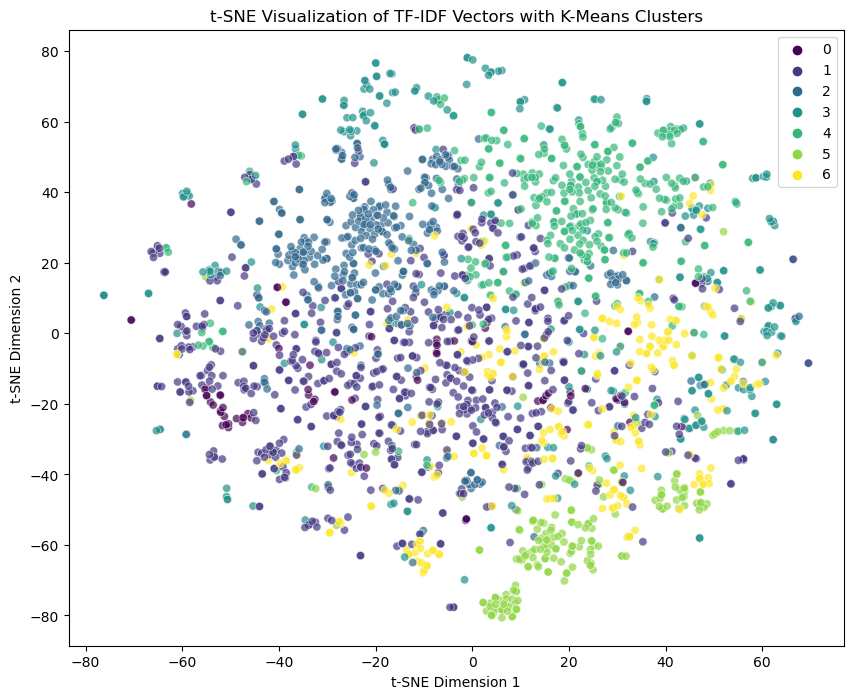

In [10]:
# Apply K-Means clustering on the TF-IDF vectors
num_clusters = 7
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(tfidf_dense)

# Visualize the clusters in 2D space
plt.figure(figsize=(10, 8))
sns.scatterplot(x=tfidf_tsne[:, 0], y=tfidf_tsne[:, 1],
                hue=clusters, palette='viridis', legend='full', alpha=0.7)
plt.title('t-SNE Visualization of TF-IDF Vectors with K-Means Clusters')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig("tsne_clusters.png", dpi=300)
plt.show()

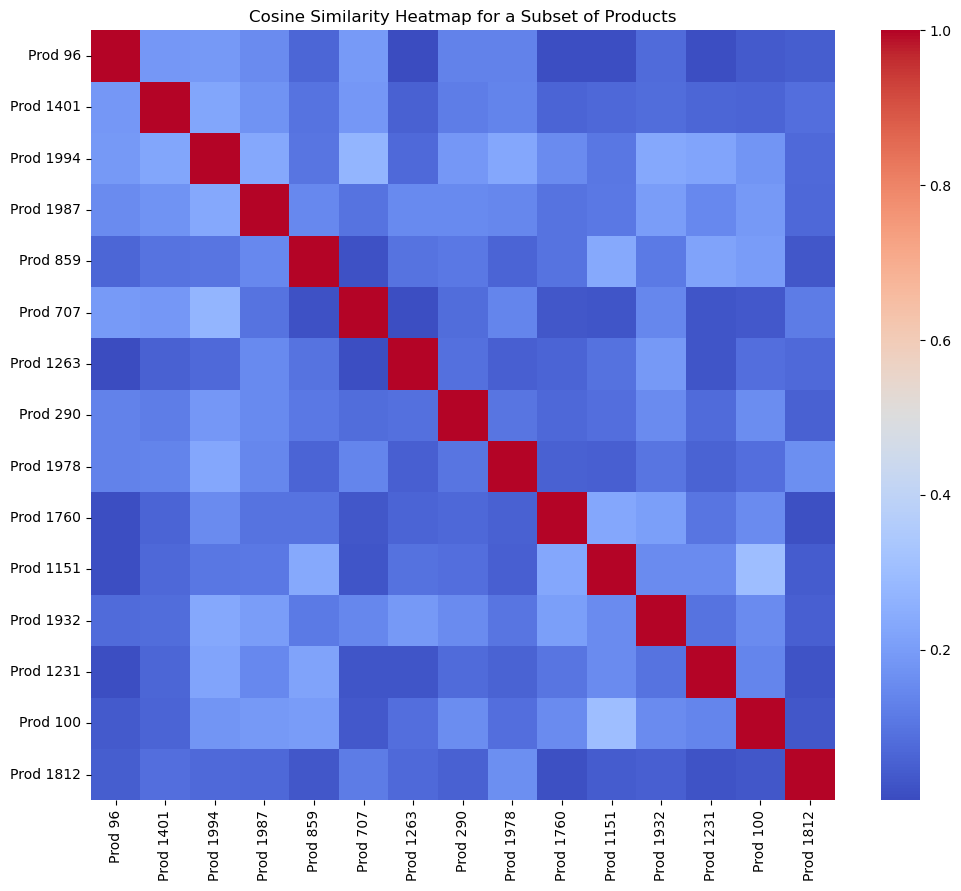

In [11]:
# For demonstration, select a random subset of 50 products
subset_size = 15
np.random.seed(42)
subset_indices = np.random.choice(tfidf_matrix_unique.shape[0], subset_size, replace=False)
tfidf_subset = tfidf_matrix_unique[subset_indices]

# Compute the cosine similarity matrix for the subset
cosine_sim_matrix = cosine_similarity(tfidf_subset)

# Create a DataFrame for better labeling in the heatmap
sim_df = pd.DataFrame(cosine_sim_matrix, 
                      index=[f"Prod {i}" for i in subset_indices],
                      columns=[f"Prod {i}" for i in subset_indices])

plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, annot=False, cmap='coolwarm')
plt.title('Cosine Similarity Heatmap for a Subset of Products')
plt.savefig("cosine_similarity_heatmap.png", dpi=300)
plt.show()

## Content and user attributes Based 


- User Attributes & Filters:
The function accepts optional parameters for user attributes (skin tone, skin type, eye color, hair color), product category, brand, and price range. This lets you narrow down the dataset based on what the customer cares about.

- Ingredient Preference:
Instead of asking the user for a specific ingredient string, the function takes an ingredient_preference parameter. This can be "water", "silicone", or "both", which tells the system which type of ingredient profile the customer wants.

- Vectorizer & TF-IDF Matrix:
The function requires a pre-fitted TF-IDF vectorizer and the corresponding TF-IDF matrix (which represents each product’s cleaned ingredient text). 


- Unique Skin Tones: ['lightMedium' 'light' 'medium' 'fair' 'deep' 'porcelain'
 'mediumTan' 'dark' 'rich' 'fairLight' 'olive' 'tan']
- Unique Skin Types: ['normal' 'dry' 'combination' 'oily']
- Unique Eye Colors: ['hazel' 'brown' 'blue' 'green' 'gray' 'Grey']
- Unique Hair Colors: ['gray' 'brown' 'black' 'blonde' 'brunette' 'auburn' 'red']
- Unique Secondary Categories: ['Eye Care' 'Treatments' 'Moisturizers' 'Cleansers'
 'Lip Balms & Treatments' 'Masks' 'Sunscreen' 'Value & Gift Sets'
 'High Tech Tools' 'Wellness' 'Self Tanners' 'Mini Size']

In [12]:
# Inspect unique values for key user attributes and filters:
unique_skin_tones = df_unique['skin_tone'].unique()
unique_skin_types = df_unique['skin_type'].unique()
unique_eye_colors = df_unique['eye_color'].unique()
unique_hair_colors = df_unique['hair_color'].unique()
unique_secondary_categories = df_unique['secondary_category'].unique()
unique_brands = df_unique['brand_name'].unique()

print("Unique Skin Tones:", unique_skin_tones)
print("Unique Skin Types:", unique_skin_types)
print("Unique Eye Colors:", unique_eye_colors)
print("Unique Hair Colors:", unique_hair_colors)
print("Unique Secondary Categories:", unique_secondary_categories)
print("Unique Brands:", unique_brands)


Unique Skin Tones: ['lightMedium' 'light' 'Unknown' 'medium' 'fair' 'deep' 'porcelain'
 'mediumTan' 'dark' 'rich' 'fairLight' 'olive' 'tan' 'notSureST']
Unique Skin Types: ['normal' 'dry' 'combination' 'oily' 'Unknown']
Unique Eye Colors: ['hazel' 'brown' 'blue' 'Unknown' 'green' 'gray' 'Grey']
Unique Hair Colors: ['gray' 'brown' 'black' 'blonde' 'Unknown' 'brunette' 'auburn' 'red']
Unique Secondary Categories: ['Eye Care' 'Treatments' 'Moisturizers' 'Cleansers'
 'Lip Balms & Treatments' 'Masks' 'Sunscreen' 'Value & Gift Sets'
 'High Tech Tools' 'Wellness' 'Self Tanners' 'Mini Size']
Unique Brands: ['Murad' 'Peter Thomas Roth' 'Caudalie' 'CLINIQUE' 'fresh' 'Jack Black'
 'Rosebud Perfume Co.' 'Shiseido' 'REN Clean Skincare' 'Lancôme'
 'Josie Maran' 'Kate Somerville' 'First Aid Beauty'
 'Dr. Dennis Gross Skincare' 'Bobbi Brown' 'GLO Science' 'Algenist'
 'Origins' 'Sunday Riley' 'Dior' 'SK-II' 'tarte' 'Clarins' 'Tata Harper'
 'Estée Lauder' 'Dr. Brandt Skincare' 'NuFACE' 'HUM Nutrition'
 

In [ ]:
def hybrid_recommendation(
    skintone=None,
    skintype=None,
    eyecolor=None,
    haircolor=None,
    secondary_category=None,
    brand_filter=None,
    price_range=None,
    ingredient_preference=None,  # "water", "silicone", "both", or None
    price_order=None,
    num_recommendations=10,
    vectorizer=None,
    tfidf_matrix=None,
    df=None
):
    """
    Hybrid recommendation system that combines user attribute filtering with 
    ingredient-based similarity via TF-IDF vectorization.

    Parameters:
        skintone (str, optional): User's skin tone.
        skintype (str, optional): User's skin type.
        eyecolor (str, optional): User's eye color.
        haircolor (str, optional): User's hair color.
        secondary_category (str, optional): Product category filter.
        brand_filter (str, optional): Brand filter.
        price_range (tuple, optional): (min_price, max_price).
        ingredient_preference (str, optional): "water", "silicone", "both", or None.
        price_order (str, optional): "asc" or "desc" for price sorting.
        num_recommendations (int): Number of products to return.
        vectorizer (TfidfVectorizer): A fitted TF-IDF vectorizer.
        tfidf_matrix (sparse matrix): TF-IDF matrix corresponding to df.
        df (pd.DataFrame): Main DataFrame with required columns.
    
    Returns:
        pd.DataFrame: DataFrame with top recommended products.
    """
    if df is None or vectorizer is None or tfidf_matrix is None:
        raise ValueError("Please provide the DataFrame, vectorizer, and tfidf_matrix.")

    # Work on a copy to avoid modifying the original DataFrame
    filtered_df = df.copy()

    # 1. Filter by user attributes (if provided)
    if skintone and skintone.lower() != "all":
        filtered_df = filtered_df[filtered_df['skin_tone'].str.lower() == skintone.lower()]
    if skintype and skintype.lower() != "all":
        filtered_df = filtered_df[filtered_df['skin_type'].str.lower() == skintype.lower()]
    if eyecolor and eyecolor.lower() != "all":
        filtered_df = filtered_df[filtered_df['eye_color'].str.lower() == eyecolor.lower()]
    if haircolor and haircolor.lower() != "all":
        filtered_df = filtered_df[filtered_df['hair_color'].str.lower() == haircolor.lower()]

    # 2. Filter by secondary category (partial match)
    if secondary_category and secondary_category.lower() != "all":
        filtered_df = filtered_df[
            filtered_df['secondary_category']
            .str.lower()
            .str.contains(secondary_category.lower(), na=False)
        ]

    # 3. Filter by brand
    if brand_filter and brand_filter.lower() != "all":
        filtered_df = filtered_df[filtered_df['brand_name'].str.lower() == brand_filter.lower()]

    # 4. Filter by price range
    if price_range and len(price_range) == 2:
        min_price, max_price = price_range
        filtered_df = filtered_df[
            (filtered_df['price_usd'] >= min_price) & (filtered_df['price_usd'] <= max_price)
        ]

    # If no products remain after filtering, return an empty DataFrame.
    if filtered_df.empty:
        print("No products found with the specified criteria.")
        return pd.DataFrame()

    # 5. Ingredient-based similarity using vectorization
    #    Create a synthetic query based on the ingredient preference.
    if ingredient_preference:
        ingredient_preference = ingredient_preference.lower()
        if ingredient_preference == "water":
            query_text = "water aqua hydrosol"
        elif ingredient_preference == "silicone":
            query_text = "silicone cyclopentasiloxane dimethicone"
        elif ingredient_preference == "both":
            query_text = "water aqua hydrosol silicone cyclopentasiloxane dimethicone"
        else:
            print("Invalid ingredient_preference. Choose 'water', 'silicone', 'both', or None.")
            return pd.DataFrame()
        
        # Transform the synthetic query text using the TF-IDF vectorizer
        input_vector = vectorizer.transform([query_text])
        
        # Get indices of the filtered products (assumes df and tfidf_matrix are aligned)
        valid_indices = filtered_df.index
        
        # Compute cosine similarity scores between the query and the filtered products
        similarity_scores = cosine_similarity(input_vector, tfidf_matrix[valid_indices]).flatten()
        
        # Add the similarity score to the filtered DataFrame
        filtered_df = filtered_df.copy()  # avoid SettingWithCopyWarning
        filtered_df['similarity_score'] = similarity_scores
    else:
        # If no ingredient preference is provided, set a default similarity score of 0.
        filtered_df = filtered_df.copy()
        filtered_df['similarity_score'] = 0.0

    # 6. Sorting: Use price_order if provided; otherwise, sort by similarity_score then rating.
    if price_order:
        if price_order.lower() == "asc":
            filtered_df = filtered_df.sort_values(by=['price_usd', 'similarity_score'], ascending=[True, False])
        elif price_order.lower() == "desc":
            filtered_df = filtered_df.sort_values(by=['price_usd', 'similarity_score'], ascending=[False, False])
        else:
            print("Invalid price_order value. Using default sorting.")
            filtered_df = filtered_df.sort_values(by=['similarity_score', 'rating'], ascending=[False, False])
    else:
        filtered_df = filtered_df.sort_values(by=['similarity_score', 'rating'], ascending=[False, False])

    # 7. Remove duplicate products and select top N recommendations
    filtered_df = filtered_df.drop_duplicates(subset=['product_id'])
    final_df = filtered_df.head(num_recommendations).copy()

    # 8. Select and order relevant columns for output
    final_df = final_df[[
        'product_id',
        'product_name',
        'brand_name',
        'price_usd',
        'rating',
    ]]

    return final_df

# Example usage:
recommendations = hybrid_recommendation(
    skintone='fair', 
    skintype='dry', 
    eyecolor=None,
    haircolor=None,
    secondary_category="moisturizers", 
    brand_filter=None, 
    price_range=(10, 100),
    ingredient_preference="water",  
    price_order="asc",
    num_recommendations=10,
    vectorizer=vectorizer,          # Pre-fitted TF-IDF vectorizer
    tfidf_matrix=tfidf_matrix_unique,  # TF-IDF matrix built on df_unique
    df=df_unique                    # Use the deduplicated DataFrame here
)

print(recommendations)

     product_id                                       product_name  \
1827    P483146               Ultra Glow Toner with Vitamins C + E   
2010    P502756  SuperSolutions 10% Urea Moisturizer Textured S...   
715     P442843                       Eczema+ Dermatitis Face Balm   
135     P384821     Take The Day Off  Cleansing Oil Makeup Remover   
1677    P480447  10 + 10 Moisturizer with 10% Vitamin C + 10% P...   
1614    P479327             Plum Plump Hyaluronic Acid Moisturizer   
236     P404793             Sunshine Vitamin C + Squalane Face Oil   
1423    P472471           Acne Remedy Overnight Repair Moisturizer   
1939    P501005  Premium BB Tinted Moisturizer with Niacinamide...   
862     P449150                                      Hydrating Oil   

                   brand_name  price_usd  rating  
1827       SEPHORA COLLECTION      14.00     5.0  
2010           The INKEY List      19.99     5.0  
715                   Skinfix      29.00     2.0  
135                  CLIN

In [ ]:
def hybrid_recommendation(
    secondary_category=None,
    skintone=None,
    skintype=None,
    eyecolor=None,
    haircolor=None,
    brand_filter=None,
    price_range=None,
    price_order=None,
    num_recommendations=10,
    df=None
):
    """
    Hybrid recommendation system that:
      1. Filters the dataset by secondary category and user attributes.
      2. Filters by brand and price range.
      3. Creates a composite text field that includes both the cleaned ingredients and
         product attribute features (if available) for TF-IDF vectorization.
      4. Vectorizes a synthetic user query built from the user's attribute inputs.
      5. Recommends products based on cosine similarity between the query and product vectors.
      
    Parameters:
      secondary_category (str, optional): Product category filter (e.g., "moisturizers").
      skintone (str, optional): User's skin tone.
      skintype (str, optional): User's skin type.
      eyecolor (str, optional): User's eye color.
      haircolor (str, optional): User's hair color.
      brand_filter (str, optional): Brand filter.
      price_range (tuple, optional): (min_price, max_price).
      price_order (str, optional): "asc" or "desc" for sorting by price.
      num_recommendations (int): Number of products to return.
      df (pd.DataFrame): Main DataFrame with required columns.
      
    Returns:
      pd.DataFrame: DataFrame with top recommended products.
    """
    
    # 1. Filter by secondary category.
    filtered_df = df.copy()
    if secondary_category and secondary_category.lower() != "all":
        filtered_df = filtered_df[
            filtered_df['secondary_category']
            .str.lower()
            .str.contains(secondary_category.lower(), na=False)
        ]
    
    # 2. Further filter by user attributes.
    if skintone and skintone.lower() not in ["all", "unknown"]:
        filtered_df = filtered_df[filtered_df['skin_tone'].str.lower() == skintone.lower()]
    if skintype and skintype.lower() not in ["all", "unknown"]:
        filtered_df = filtered_df[filtered_df['skin_type'].str.lower() == skintype.lower()]
    if eyecolor and eyecolor.lower() not in ["all", "unknown"]:
        filtered_df = filtered_df[filtered_df['eye_color'].str.lower() == eyecolor.lower()]
    if haircolor and haircolor.lower() not in ["all", "unknown"]:
        filtered_df = filtered_df[filtered_df['hair_color'].str.lower() == haircolor.lower()]
    
    # 3. Filter by brand if provided.
    if brand_filter and brand_filter.lower() != "all":
        filtered_df = filtered_df[filtered_df['brand_name'].str.lower() == brand_filter.lower()]
    
    # 4. Filter by price range.
    if price_range and len(price_range) == 2:
        min_price, max_price = price_range
        filtered_df = filtered_df[
            (filtered_df['price_usd'] >= min_price) & (filtered_df['price_usd'] <= max_price)
        ]
    
    if filtered_df.empty:
        print("No products found with the specified criteria.")
        return pd.DataFrame()
    
    # 5. Create a composite text field that includes both the ingredients and the attributes.
    #    This composite text is used for TF-IDF vectorization.
    filtered_df['composite_text'] = (
        filtered_df['ingredients_cleaned'] + " " +
        filtered_df['skin_tone'].fillna('') + " " +
        filtered_df['skin_type'].fillna('') + " " +
        filtered_df['eye_color'].fillna('') + " " +
        filtered_df['hair_color'].fillna('')
    )
    
    # 6 Build the TF-IDF matrix on the composite text.
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(filtered_df['composite_text'])
    
    # 7. Build the user query from provided user attributes.
    user_query_parts = []
    for attr in [skintone, skintype, eyecolor, haircolor]:
        if attr and attr.lower() not in ["all", "unknown"]:
            user_query_parts.append(attr.lower())
    user_query = " ".join(user_query_parts)
    
    # If no attributes provided, default to an empty query.
    if not user_query:
        user_query = ""
    
    # 8. Vectorize the user query using the same vectorizer.
    input_vector = vectorizer.transform([user_query])
    
    # 9. Compute cosine similarity between the user query and each product's TF-IDF vector.
    similarity_scores = cosine_similarity(input_vector, tfidf_matrix).flatten()
    filtered_df['similarity_score'] = similarity_scores
    
    # 10. Sort the results.
    if price_order:
        if price_order.lower() == "asc":
            filtered_df = filtered_df.sort_values(by=['price_usd', 'similarity_score'], ascending=[True, False])
        elif price_order.lower() == "desc":
            filtered_df = filtered_df.sort_values(by=['price_usd', 'similarity_score'], ascending=[False, False])
        else:
            print("Invalid price_order value. Defaulting to sorting by similarity and rating.")
            filtered_df = filtered_df.sort_values(by=['similarity_score', 'rating'], ascending=[False, False])
    else:
        filtered_df = filtered_df.sort_values(by=['similarity_score', 'rating'], ascending=[False, False])
    
    # 11. Remove duplicate products and select top N recommendations.
    filtered_df = filtered_df.drop_duplicates(subset=['product_id'])
    final_df = filtered_df.head(num_recommendations).copy()
    
    # 12. Return only the relevant output columns.
    final_df = final_df[['product_id', 'product_name', 'brand_name', 'price_usd', 'rating']]
    return final_df

# Example usage:
# Assuming df_unique is your deduplicated DataFrame with columns:
# 'product_id', 'product_name', 'brand_name', 'price_usd', 'rating', 'ingredients_cleaned',
# 'skin_tone', 'skin_type', 'eye_color', 'hair_color', and 'secondary_category'.
recommendations = hybrid_recommendation(
    secondary_category="moisturizers",
    skintone="fair",
    skintype="dry",
    eyecolor="blue",
    haircolor="blonde",
    brand_filter=None,
    price_range=(10, 100),
    price_order="asc",
    num_recommendations=10,
    df=df_unique
)

print(recommendations)


     product_id                                       product_name  \
576     P434360  High-Potency Night-a-Mins Resurfacing Cream wi...   
972     P455610                         Confidence in a Neck Cream   
686     P442564    Emerald CBD + Adaptogens Deep Moisture Glow Oil   
2118    P504277  Face Stone Nourishing Solid Refillable Facial ...   
1060    P457695                            DeliKate Recovery Cream   

           brand_name  price_usd  rating  similarity_score  
576           Origins       52.0     5.0          0.069406  
972      IT Cosmetics       54.0     5.0          0.053948  
686         Herbivore       60.0     5.0          0.076382  
2118      Kate McLeod       68.0     5.0          0.178956  
1060  Kate Somerville       76.0     5.0          0.076294  
